# YZM304 Derin Öğrenme Proje Ödevi I
## Stroke Veri Seti ile İkili Sınıflandırma ve MLP Karşılaştırması

Bu notebook, verilen ödev maddelerini doğrudan karşılayacak şekilde hazırlanmıştır. Akış şu sırayla ilerler:

- Veri setini tanıma ve temel veri analizi
- Eksik değer ve sınıf dengesizliği incelemesi
- Ön işleme ve `train/validation/test` ayrımı
- Laboratuvar mantığını temsil eden NumPy tabanlı temel MLP
- Daha derin ve regülarize MLP denemeleri
- Aynı mimarinin `scikit-learn MLPClassifier` ile yeniden yazımı
- Karmaşıklık matrisi ve temel performans ölçümleri
- Overfitting / underfitting yorumu ve kısa sonuç

## Çalışma Notu

Bu veri setinde `stroke=1` sınıfı oldukça azdır. Bu yüzden yalnızca `accuracy` kullanmak yanıltıcı olabilir. Notebook boyunca model seçimi için özellikle şu ölçütler izlenecektir:

- `F1-score`
- `Recall`
- `ROC-AUC`

Yani burada yüksek doğruluk tek başına yeterli kabul edilmeyecektir.

In [18]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelBinarizer, OneHotEncoder, StandardScaler
from sklearn.utils import check_random_state

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

DATA_PATH = Path("healthcare-dataset-stroke-data.csv")
df = pd.read_csv(DATA_PATH)

print(f"Veri seti yolu: {DATA_PATH.resolve()}")
print(f"Gözlem sayısı: {df.shape[0]}")
print(f"Sütun sayısı: {df.shape[1]}")

Veri seti yolu: C:\Users\hsena\Downloads\stroke_dataset\healthcare-dataset-stroke-data.csv
Gözlem sayısı: 5110
Sütun sayısı: 12


## 1. Veriyi Yükleme ve İlk Bakış

Önce veri setinin ilk satırlarına ve sütun tiplerine bakıyoruz. Böylece hangi değişkenlerin sayısal, hangilerinin kategorik olduğunu netleştirmiş oluyoruz.

In [19]:
display(df.head())

column_summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_ratio_%": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(),
    }
)

display(column_summary)
df.info()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0000,0,1,Yes,Private,Urban,228.6900,36.6000,formerly smoked,1
1,51676,Female,61.0000,0,0,Yes,Self-employed,Rural,202.2100,NaN,never smoked,1
2,31112,Male,80.0000,0,1,Yes,Private,Rural,105.9200,32.5000,never smoked,1
3,60182,Female,49.0000,0,0,Yes,Private,Urban,171.2300,34.4000,smokes,1
4,1665,Female,79.0000,1,0,Yes,Self-employed,Rural,174.1200,24.0000,never smoked,1


,dtype,missing_count,missing_ratio_%,n_unique
id,int64,0,0.0000,5110
gender,str,0,0.0000,3
age,float64,0,0.0000,104
hypertension,int64,0,0.0000,2
heart_disease,int64,0,0.0000,2
ever_married,str,0,0.0000,2
work_type,str,0,0.0000,5
Residence_type,str,0,0.0000,2
avg_glucose_level,float64,0,0.0000,3979
bmi,float64,201,3.9300,418


<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


## 2. Eksik Değerler ve Hedef Değişken

Bu bölümde iki kritik soruya cevap veriyoruz:

1. Eksik değer var mı?
2. Hedef değişken dengeli mi?

Eğer hedef dengesizse, model değerlendirme stratejimizi ona göre değiştirmemiz gerekir.

In [20]:
missing_table = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_ratio_percent=lambda x: (100 * x["missing_count"] / len(df)).round(2))
)

target_table = (
    df["stroke"]
    .value_counts()
    .sort_index()
    .rename_axis("stroke")
    .to_frame("count")
    .assign(ratio_percent=lambda x: (100 * x["count"] / len(df)).round(2))
)

display(missing_table)
display(target_table)

,missing_count,missing_ratio_percent
id,0,0.0000
gender,0,0.0000
age,0,0.0000
hypertension,0,0.0000
heart_disease,0,0.0000
ever_married,0,0.0000
work_type,0,0.0000
Residence_type,0,0.0000
avg_glucose_level,0,0.0000
bmi,201,3.9300


,count,ratio_percent
stroke,,
0,4861,95.1300
1,249,4.8700


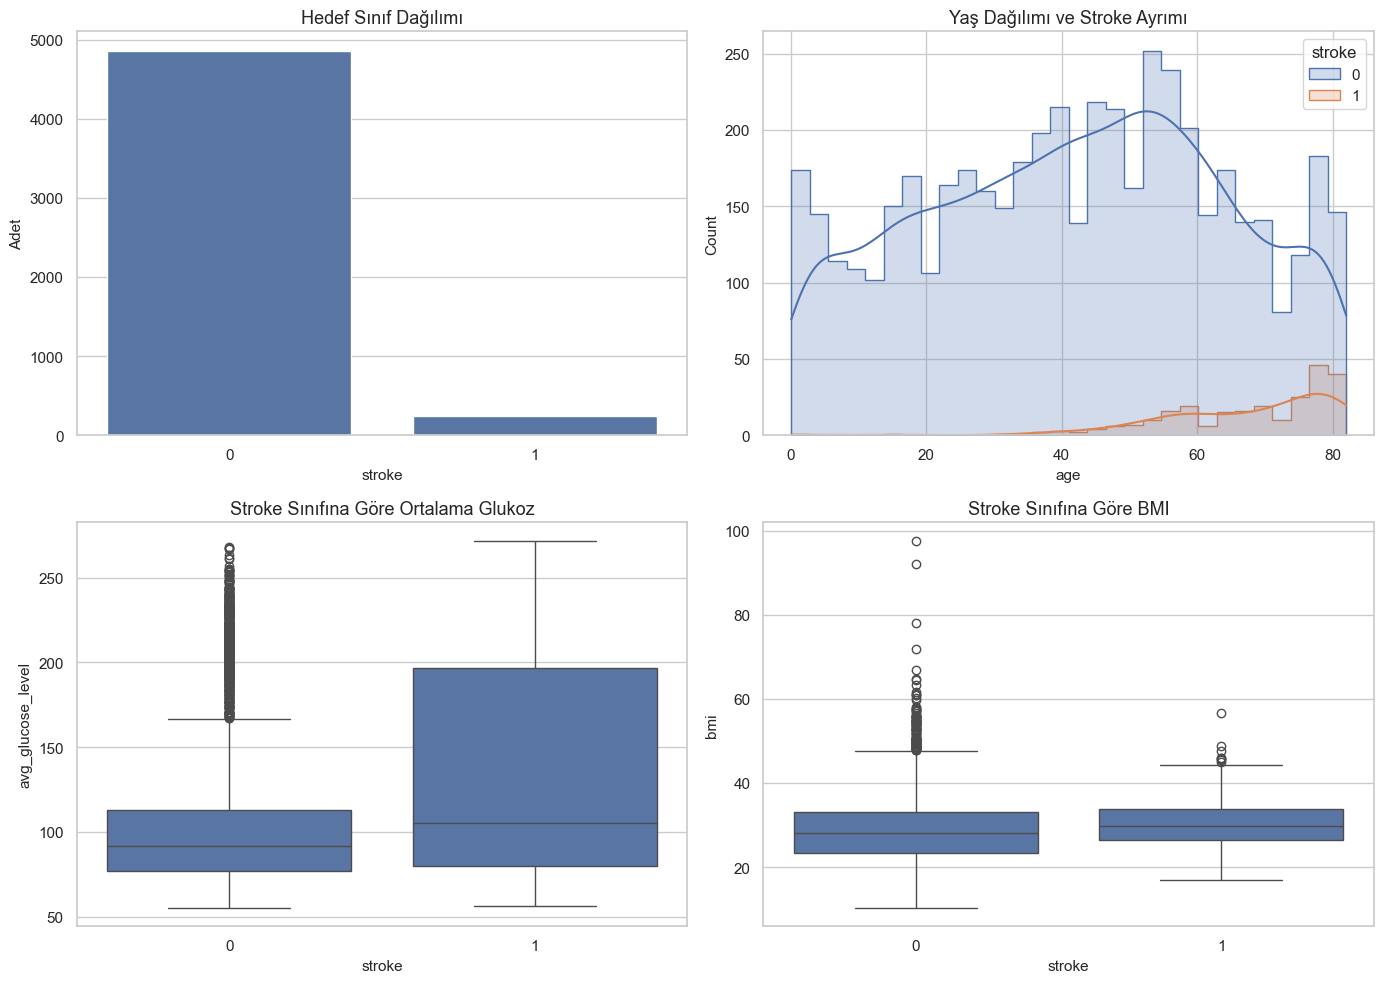

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x="stroke", ax=axes[0, 0])
axes[0, 0].set_title("Hedef Sınıf Dağılımı")
axes[0, 0].set_xlabel("stroke")
axes[0, 0].set_ylabel("Adet")

sns.histplot(data=df, x="age", hue="stroke", bins=30, kde=True, ax=axes[0, 1], element="step")
axes[0, 1].set_title("Yaş Dağılımı ve Stroke Ayrımı")

sns.boxplot(data=df, x="stroke", y="avg_glucose_level", ax=axes[1, 0])
axes[1, 0].set_title("Stroke Sınıfına Göre Ortalama Glukoz")

sns.boxplot(data=df, x="stroke", y="bmi", ax=axes[1, 1])
axes[1, 1].set_title("Stroke Sınıfına Göre BMI")

plt.tight_layout()
plt.show()

### İlk Yorumlar

- `bmi` sütununda eksik değerler vardır; diğer sütunlar tamdır.
- `stroke=1` oranı çok düşüktür. Bu, veri setinin belirgin biçimde dengesiz olduğunu gösterir.
- Yaş ve ortalama glukoz seviyesi arttıkça stroke riski artıyor gibi görünmektedir.
- Sınıf dengesizliği nedeniyle modelin negatif sınıfa aşırı kayması beklenebilir; bu yüzden karar eşiği (`threshold`) analizi önemlidir.

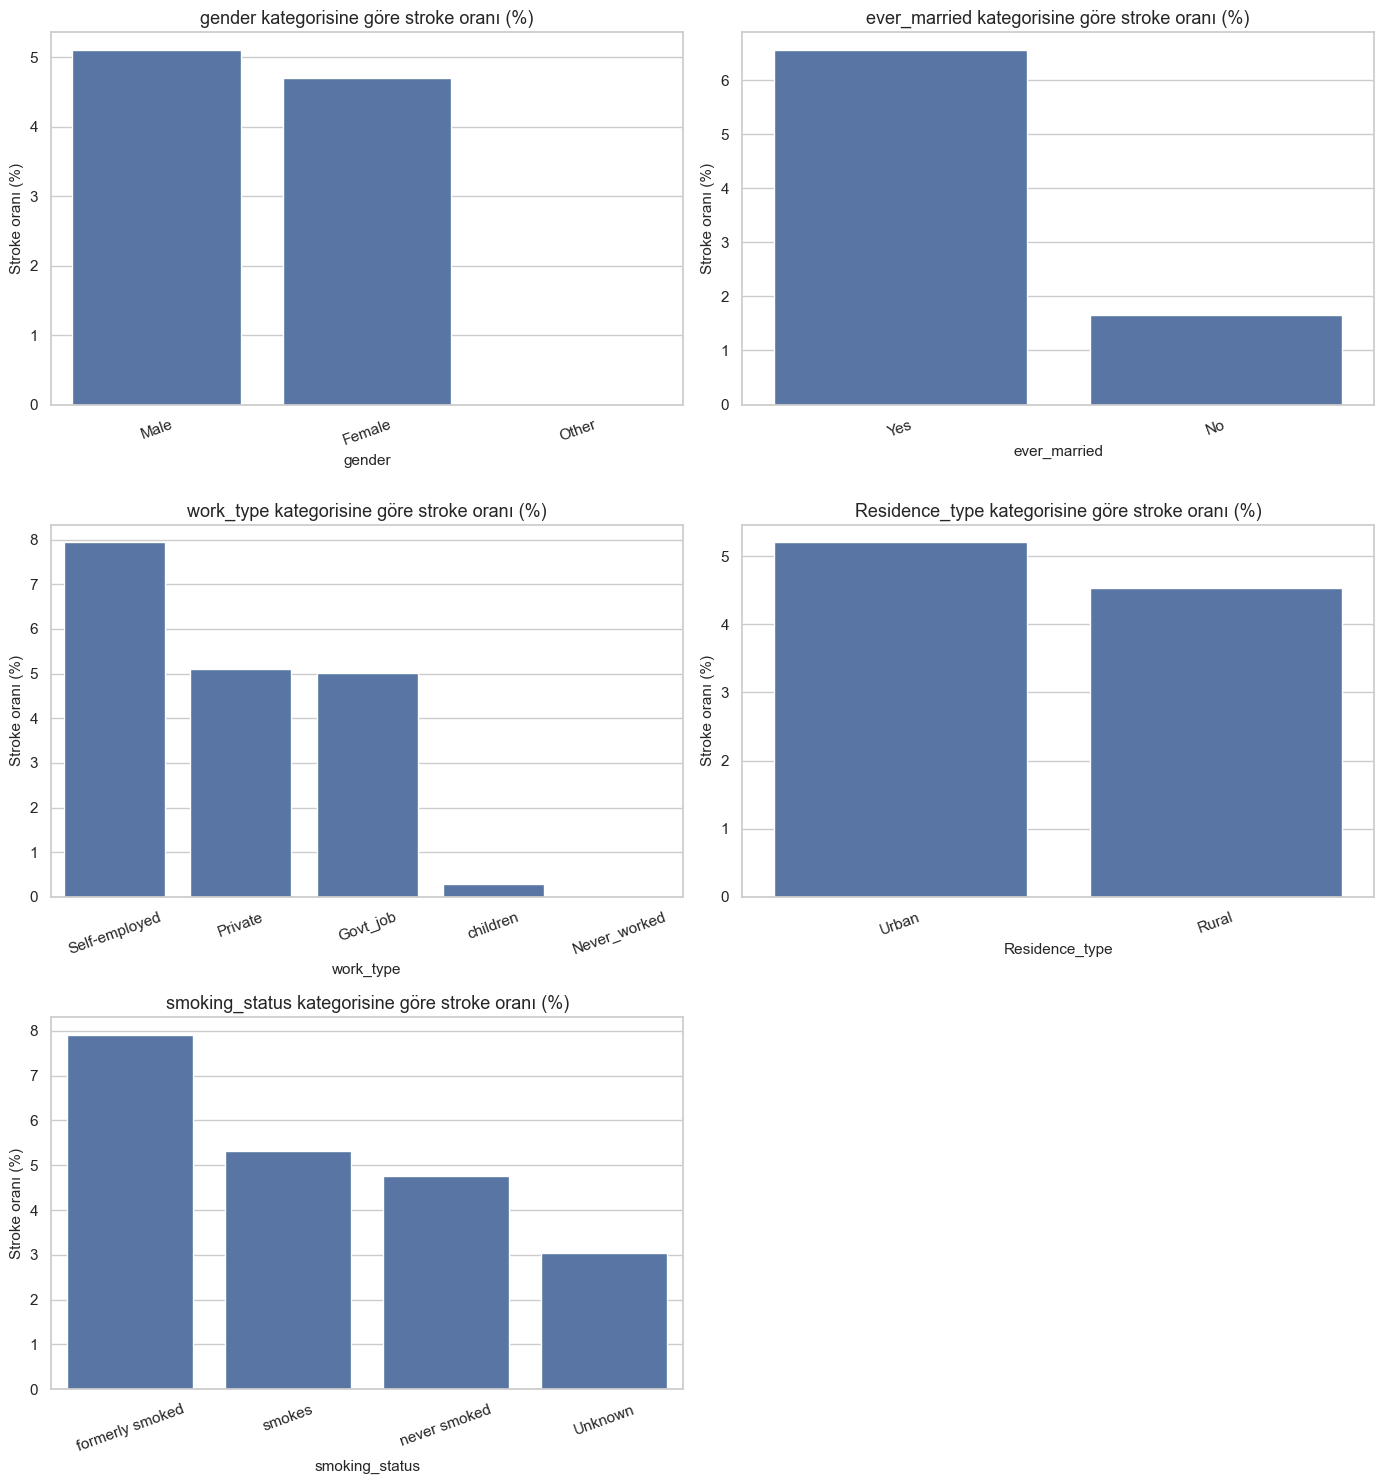

In [22]:
categorical_columns = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()

for ax, column in zip(axes, categorical_columns):
    rate_table = (
        df.groupby(column, dropna=False)["stroke"]
        .mean()
        .sort_values(ascending=False)
        .mul(100)
        .reset_index()
    )
    sns.barplot(data=rate_table, x=column, y="stroke", ax=ax)
    ax.set_title(f"{column} kategorisine göre stroke oranı (%)")
    ax.set_ylabel("Stroke oranı (%)")
    ax.tick_params(axis="x", rotation=20)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

## 3. Ön İşleme Stratejisi

Model kurmadan önce aşağıdaki kararlar uygulanacaktır:

- `id` sütunu yalnızca kimlik bilgisidir, bu yüzden modele alınmayacaktır.
- `bmi` eksikleri medyan ile doldurulacaktır.
- Sürekli sayısal değişkenler standardize edilecektir.
- Kategorik değişkenler `One-Hot Encoding` ile sayısallaştırılacaktır.
- Veri, sınıf oranı korunacak şekilde `train / validation / test` olarak ayrılacaktır.

Bu kurgu, hem adil model karşılaştırması yapmayı hem de overfitting incelemesini mümkün hale getirir.

In [23]:
target_col = "stroke"

continuous_features = ["age", "avg_glucose_level", "bmi"]
binary_features = ["hypertension", "heart_disease"]
categorical_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

X = df.drop(columns=[target_col, "id"])
y = df[target_col].astype(int)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=SEED,
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            continuous_features,
        ),
        ("bin", "passthrough", binary_features),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

y_train_array = y_train.to_numpy().reshape(-1, 1)
y_val_array = y_val.to_numpy().reshape(-1, 1)
y_test_array = y_test.to_numpy().reshape(-1, 1)

split_table = pd.DataFrame(
    [
        {
            "split": "train",
            "n_samples": len(y_train),
            "stroke_ratio_%": y_train.mean() * 100,
        },
        {
            "split": "validation",
            "n_samples": len(y_val),
            "stroke_ratio_%": y_val.mean() * 100,
        },
        {
            "split": "test",
            "n_samples": len(y_test),
            "stroke_ratio_%": y_test.mean() * 100,
        },
    ]
)

feature_names = preprocessor.get_feature_names_out()

display(split_table.round(2))
print(f"Ön işleme sonrası özellik sayısı: {X_train_processed.shape[1]}")
print("İlk 10 dönüştürülmüş özellik:")
print(feature_names[:10])

,split,n_samples,stroke_ratio_%
0,train,3270,4.8600
1,validation,818,4.8900
2,test,1022,4.8900


Ön işleme sonrası özellik sayısı: 21
İlk 10 dönüştürülmüş özellik:
['num__age' 'num__avg_glucose_level' 'num__bmi' 'bin__hypertension'
 'bin__heart_disease' 'cat__gender_Female' 'cat__gender_Male'
 'cat__gender_Other' 'cat__ever_married_No' 'cat__ever_married_Yes']


## 3.1 Deney Tasarımı ve Hiperparametre Özeti

Bu bölümde deneylerin tekrarlanabilir olması için temel ayarlar toplu halde verilmektedir.

Özellikle `NumPy` ile yazılan temel model ve `scikit-learn MLPClassifier` karşılaştırması şu sabit koşullarda yapılacaktır:

- Aynı `train / validation / test` ayrımı
- Aynı mimari: `1` gizli katman, `16` nöron
- Aynı optimizasyon mantığı: `SGD`
- Aynı öğrenme oranı ve batch boyutu
- Aynı başlangıç ağırlıkları
- Aynı dış doğrulama (`validation`) kümesi

Daha sonra ayrıca iyileştirme amacıyla ağırlıklı kayıp ve daha derin mimari de denenecektir.

In [24]:
experiment_plan = pd.DataFrame(
    [
        {
            "experiment": "NumPy temel model",
            "architecture": "(16,)",
            "optimizer": "Mini-batch SGD",
            "learning_rate": 0.03,
            "batch_size": 64,
            "epochs": 120,
            "shuffle": False,
            "same_init_as_sklearn": True,
            "regularization": "Yok",
        },
        {
            "experiment": "scikit-learn temel model",
            "architecture": "(16,)",
            "optimizer": "SGD (momentum=0)",
            "learning_rate": 0.03,
            "batch_size": 64,
            "epochs": 120,
            "shuffle": False,
            "same_init_as_numpy": True,
            "regularization": "Yok",
        },
        {
            "experiment": "NumPy ağırlıklı model",
            "architecture": "(16,)",
            "optimizer": "Mini-batch SGD",
            "learning_rate": 0.03,
            "batch_size": 64,
            "epochs": 300,
            "shuffle": True,
            "same_init_as_sklearn": False,
            "regularization": "Sınıf ağırlığı",
        },
        {
            "experiment": "NumPy derin model",
            "architecture": "(32, 16)",
            "optimizer": "Mini-batch SGD",
            "learning_rate": 0.02,
            "batch_size": 64,
            "epochs": 350,
            "shuffle": True,
            "same_init_as_sklearn": False,
            "regularization": "L2",
        },
    ]
)

display(experiment_plan)

,experiment,architecture,optimizer,learning_rate,batch_size,epochs,shuffle,same_init_as_sklearn,regularization,same_init_as_numpy
0,NumPy temel model,"(16,)",Mini-batch SGD,0.0300,64,120,False,True,Yok,NaN
1,scikit-learn temel model,"(16,)",SGD (momentum=0),0.0300,64,120,False,NaN,Yok,True
2,NumPy ağırlıklı model,"(16,)",Mini-batch SGD,0.0300,64,300,True,False,Sınıf ağırlığı,NaN
3,NumPy derin model,"(32, 16)",Mini-batch SGD,0.0200,64,350,True,False,L2,NaN


## 4. Yardımcı Fonksiyonlar

Aşağıdaki fonksiyonlar metrik hesaplama, en iyi karar eşiğini bulma, karmaşıklık matrisi çizme ve eğitim geçmişini görselleştirme için kullanılacaktır.

In [25]:
def metric_frame(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }


def find_best_threshold(y_true, y_prob):
    threshold_rows = []
    for threshold in np.linspace(0.01, 0.99, 99):
        row = metric_frame(y_true, y_prob, threshold)
        row["threshold"] = threshold
        threshold_rows.append(row)

    threshold_df = pd.DataFrame(threshold_rows)
    best_row = threshold_df.sort_values(
        by=["f1", "recall", "precision"],
        ascending=[False, False, False],
    ).iloc[0]
    return float(best_row["threshold"]), threshold_df


def build_result_row(
    model_name,
    implementation,
    architecture,
    epochs_run,
    y_val_true,
    y_val_prob,
    y_test_true,
    y_test_prob,
    best_threshold,
):
    val_metrics = metric_frame(y_val_true, y_val_prob, best_threshold)
    test_metrics = metric_frame(y_test_true, y_test_prob, best_threshold)
    test_default_metrics = metric_frame(y_test_true, y_test_prob, 0.50)

    return {
        "model_name": model_name,
        "implementation": implementation,
        "architecture": architecture,
        "epochs_run": epochs_run,
        "threshold": best_threshold,
        "val_f1": val_metrics["f1"],
        "val_recall": val_metrics["recall"],
        "val_roc_auc": val_metrics["roc_auc"],
        "test_accuracy": test_metrics["accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1": test_metrics["f1"],
        "test_roc_auc": test_metrics["roc_auc"],
        "test_f1_at_0_50": test_default_metrics["f1"],
    }


def binary_cross_entropy(y_true, y_prob):
    y_true = np.asarray(y_true).astype(float).ravel()
    y_prob = np.clip(np.asarray(y_prob).ravel(), 1e-8, 1 - 1e-8)
    return float(
        -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
    )


def shared_xavier_initialization(layer_sizes, seed=42):
    rng = np.random.default_rng(seed)
    weights = []
    biases = []

    for in_dim, out_dim in zip(layer_sizes[:-1], layer_sizes[1:]):
        limit = np.sqrt(6 / (in_dim + out_dim))
        weights.append(rng.uniform(-limit, limit, size=(in_dim, out_dim)))
        biases.append(np.zeros((1, out_dim)))

    return weights, biases


def plot_history(history, title):
    epochs = history["epoch"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs, history["train_loss"], label="train loss")
    axes[0].plot(epochs, history["val_loss"], label="validation loss")
    axes[0].set_title(f"{title} - Kayıp Eğrisi")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_accuracy"], label="train accuracy")
    axes[1].plot(epochs, history["val_accuracy"], label="validation accuracy")
    axes[1].set_title(f"{title} - Accuracy Eğrisi")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_threshold_diagnostics(threshold_df, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
    ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
    ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1-score")
    ax.set_title(title)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Metric değeri")
    ax.legend()
    plt.show()

## 5. NumPy ile Laboratuvar Tipi Temel MLP

Bu bölümde dış derin öğrenme kütüphanesi kullanmadan, NumPy ile bir çok katmanlı algılayıcı (MLP) sınıfı yazıyoruz.

Temel fikir:

- Gizli katmanlarda `ReLU`
- Çıkışta `Sigmoid`
- Kayıp fonksiyonu olarak `Binary Cross Entropy`
- Optimizasyon olarak `mini-batch SGD`

Böylece laboratuvar çalışmasının mantığını daha şeffaf biçimde yeniden kurmuş oluyoruz.

In [26]:
class BinaryMLP:
    def __init__(
        self,
        input_dim,
        hidden_layers=(16,),
        learning_rate=0.03,
        epochs=300,
        batch_size=64,
        l2_lambda=0.0,
        pos_weight=1.0,
        patience=35,
        shuffle=True,
        initial_weights=None,
        initial_biases=None,
        seed=42,
    ):
        self.input_dim = input_dim
        self.hidden_layers = hidden_layers
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.l2_lambda = l2_lambda
        self.pos_weight = pos_weight
        self.patience = patience
        self.shuffle = shuffle
        self.initial_weights = initial_weights
        self.initial_biases = initial_biases
        self.seed = seed

        self.layer_sizes = (self.input_dim,) + tuple(self.hidden_layers) + (1,)
        self.weights = []
        self.biases = []
        self.history_ = {
            "epoch": [],
            "train_loss": [],
            "val_loss": [],
            "train_accuracy": [],
            "val_accuracy": [],
        }
        self.epochs_run_ = 0
        self._initialize_parameters()


    def _initialize_parameters(self):
        if self.initial_weights is not None and self.initial_biases is not None:
            self.weights = [weight.copy() for weight in self.initial_weights]
            self.biases = [bias.copy() for bias in self.initial_biases]
            return

        rng = np.random.default_rng(self.seed)
        for in_dim, out_dim in zip(self.layer_sizes[:-1], self.layer_sizes[1:]):
            limit = np.sqrt(6 / (in_dim + out_dim))
            self.weights.append(rng.uniform(-limit, limit, size=(in_dim, out_dim)))
            self.biases.append(np.zeros((1, out_dim)))


    @staticmethod
    def _relu(z):
        return np.maximum(0, z)


    @staticmethod
    def _relu_derivative(z):
        return (z > 0).astype(float)


    @staticmethod
    def _sigmoid(z):
        z = np.clip(z, -250, 250)
        return 1.0 / (1.0 + np.exp(-z))


    def _forward(self, X):
        activations = [X]
        pre_activations = []
        current = X

        for weight, bias in zip(self.weights[:-1], self.biases[:-1]):
            z = current @ weight + bias
            current = self._relu(z)
            pre_activations.append(z)
            activations.append(current)

        z_out = current @ self.weights[-1] + self.biases[-1]
        y_prob = self._sigmoid(z_out)
        pre_activations.append(z_out)
        activations.append(y_prob)

        return activations, pre_activations


    def _weighted_bce(self, y_true, y_prob):
        eps = 1e-8
        y_prob = np.clip(y_prob, eps, 1 - eps)
        loss = -(
            self.pos_weight * y_true * np.log(y_prob)
            + (1 - y_true) * np.log(1 - y_prob)
        )
        regularization = sum(np.sum(weight ** 2) for weight in self.weights)
        regularization *= self.l2_lambda / (2 * len(y_true))
        return float(loss.mean() + regularization)


    def _backward(self, y_true, activations, pre_activations):
        batch_size = y_true.shape[0]
        grads_w = [None] * len(self.weights)
        grads_b = [None] * len(self.biases)

        y_prob = np.clip(activations[-1], 1e-8, 1 - 1e-8)
        delta = (
            ((1 - y_true) * y_prob) - (self.pos_weight * y_true * (1 - y_prob))
        ) / batch_size

        grads_w[-1] = (
            activations[-2].T @ delta
            + (self.l2_lambda / batch_size) * self.weights[-1]
        )
        grads_b[-1] = np.sum(delta, axis=0, keepdims=True)

        for layer_index in range(len(self.weights) - 2, -1, -1):
            delta = (
                delta @ self.weights[layer_index + 1].T
            ) * self._relu_derivative(pre_activations[layer_index])

            grads_w[layer_index] = (
                activations[layer_index].T @ delta
                + (self.l2_lambda / batch_size) * self.weights[layer_index]
            )
            grads_b[layer_index] = np.sum(delta, axis=0, keepdims=True)

        return grads_w, grads_b


    def predict_proba(self, X):
        return self._forward(X)[0][-1]


    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


    def fit(self, X_train, y_train, X_val, y_val):
        n_samples = X_train.shape[0]
        best_val_loss = np.inf
        best_weights = [weight.copy() for weight in self.weights]
        best_biases = [bias.copy() for bias in self.biases]
        wait = 0

        for epoch in range(1, self.epochs + 1):
            if self.shuffle:
                rng = np.random.default_rng(self.seed + epoch)
                shuffled_idx = rng.permutation(n_samples)
                X_shuffled = X_train[shuffled_idx]
                y_shuffled = y_train[shuffled_idx]
            else:
                X_shuffled = X_train
                y_shuffled = y_train

            for start in range(0, n_samples, self.batch_size):
                stop = start + self.batch_size
                xb = X_shuffled[start:stop]
                yb = y_shuffled[start:stop]

                activations, pre_activations = self._forward(xb)
                grads_w, grads_b = self._backward(yb, activations, pre_activations)

                for i in range(len(self.weights)):
                    self.weights[i] -= self.learning_rate * grads_w[i]
                    self.biases[i] -= self.learning_rate * grads_b[i]

            train_prob = self.predict_proba(X_train)
            val_prob = self.predict_proba(X_val)

            train_pred = (train_prob >= 0.5).astype(int)
            val_pred = (val_prob >= 0.5).astype(int)

            train_loss = self._weighted_bce(y_train, train_prob)
            val_loss = self._weighted_bce(y_val, val_prob)

            self.history_["epoch"].append(epoch)
            self.history_["train_loss"].append(train_loss)
            self.history_["val_loss"].append(val_loss)
            self.history_["train_accuracy"].append(float((train_pred == y_train).mean()))
            self.history_["val_accuracy"].append(float((val_pred == y_val).mean()))

            if self.patience is not None:
                if val_loss < best_val_loss - 1e-5:
                    best_val_loss = val_loss
                    best_weights = [weight.copy() for weight in self.weights]
                    best_biases = [bias.copy() for bias in self.biases]
                    wait = 0
                else:
                    wait += 1
                    if wait >= self.patience:
                        break
            else:
                best_weights = [weight.copy() for weight in self.weights]
                best_biases = [bias.copy() for bias in self.biases]

        self.weights = best_weights
        self.biases = best_biases
        self.epochs_run_ = len(self.history_["epoch"])
        return self

In [27]:
def train_sklearn_with_shared_init(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layers=(16,),
    learning_rate=0.03,
    epochs=120,
    batch_size=64,
    alpha=0.0,
    shuffle=False,
    seed=42,
    initial_weights=None,
    initial_biases=None,
    sample_weight=None,
):
    layer_sizes = [X_train.shape[1], *hidden_layers, 1]

    if initial_weights is None or initial_biases is None:
        initial_weights, initial_biases = shared_xavier_initialization(layer_sizes, seed=seed)

    clf = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation="relu",
        solver="sgd",
        learning_rate="constant",
        learning_rate_init=learning_rate,
        batch_size=batch_size,
        alpha=alpha,
        max_iter=1,
        warm_start=True,
        shuffle=shuffle,
        early_stopping=False,
        momentum=0.0,
        nesterovs_momentum=False,
        tol=0.0,
        random_state=seed,
    )

    clf._label_binarizer = LabelBinarizer()
    clf._label_binarizer.fit(np.array([0, 1]))
    clf.classes_ = clf._label_binarizer.classes_

    y_encoded = clf._label_binarizer.transform(y_train)
    if y_encoded.ndim == 1:
        y_encoded = y_encoded.reshape(-1, 1)

    clf._random_state = check_random_state(seed)
    clf._initialize(y_encoded, layer_sizes, X_train.dtype)
    clf.coefs_ = [weight.copy() for weight in initial_weights]
    clf.intercepts_ = [bias.ravel().copy() for bias in initial_biases]
    clf._best_coefs = [coef.copy() for coef in clf.coefs_]
    clf._best_intercepts = [intercept.copy() for intercept in clf.intercepts_]

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
    }

    classes = np.array([0, 1])

    for epoch in range(1, epochs + 1):
        clf.partial_fit(
            X_train,
            y_train,
            classes=classes,
            sample_weight=sample_weight,
        )

        train_prob = clf.predict_proba(X_train)[:, 1]
        val_prob = clf.predict_proba(X_val)[:, 1]

        history["epoch"].append(epoch)
        history["train_loss"].append(binary_cross_entropy(y_train, train_prob))
        history["val_loss"].append(binary_cross_entropy(y_val, val_prob))
        history["train_accuracy"].append(
            accuracy_score(y_train, (train_prob >= 0.5).astype(int))
        )
        history["val_accuracy"].append(
            accuracy_score(y_val, (val_prob >= 0.5).astype(int))
        )

    return clf, history

### NumPy Modelleri

Burada üç farklı NumPy modeli kuruyoruz:

- `numpy_baseline_1_hidden`: Tek gizli katmanlı temel model
- `numpy_weighted_1_hidden`: Aynı mimari fakat pozitif sınıf ağırlıklı kayıp fonksiyonu ile
- `numpy_deep_l2`: Daha derin mimari ve L2 regülarizasyonu ile

Böylece hem temel modeli hem de iyileştirme denemelerini karşılaştırabiliyoruz.

In [28]:
positive_weight = float((len(y_train) - y_train.sum()) / y_train.sum())
print(f"Pozitif sınıf ağırlığı: {positive_weight:0.2f}")

shared_baseline_weights, shared_baseline_biases = shared_xavier_initialization(
    [X_train_processed.shape[1], 16, 1],
    seed=SEED,
)

custom_model_configs = {
    "numpy_baseline_1_hidden": {
        "hidden_layers": (16,),
        "learning_rate": 0.03,
        "epochs": 120,
        "batch_size": 64,
        "l2_lambda": 0.0,
        "pos_weight": 1.0,
        "patience": None,
        "shuffle": False,
        "initial_weights": shared_baseline_weights,
        "initial_biases": shared_baseline_biases,
    },
    "numpy_weighted_1_hidden": {
        "hidden_layers": (16,),
        "learning_rate": 0.03,
        "epochs": 300,
        "batch_size": 64,
        "l2_lambda": 0.0,
        "pos_weight": positive_weight,
        "patience": 35,
        "shuffle": True,
    },
    "numpy_deep_l2": {
        "hidden_layers": (32, 16),
        "learning_rate": 0.02,
        "epochs": 350,
        "batch_size": 64,
        "l2_lambda": 1e-3,
        "pos_weight": positive_weight,
        "patience": 40,
        "shuffle": True,
    },
}

model_store = {}
result_rows = []

for model_name, config in custom_model_configs.items():
    model = BinaryMLP(
        input_dim=X_train_processed.shape[1],
        seed=SEED,
        **config,
    )
    model.fit(X_train_processed, y_train_array, X_val_processed, y_val_array)

    val_prob = model.predict_proba(X_val_processed).ravel()
    test_prob = model.predict_proba(X_test_processed).ravel()

    best_threshold, threshold_df = find_best_threshold(y_val_array, val_prob)

    model_store[model_name] = {
        "model": model,
        "implementation": "NumPy",
        "architecture": str(config["hidden_layers"]),
        "epochs_run": model.epochs_run_,
        "val_prob": val_prob,
        "test_prob": test_prob,
        "best_threshold": best_threshold,
        "threshold_df": threshold_df,
        "history": model.history_,
    }

    result_rows.append(
        build_result_row(
            model_name=model_name,
            implementation="NumPy",
            architecture=str(config["hidden_layers"]),
            epochs_run=model.epochs_run_,
            y_val_true=y_val_array,
            y_val_prob=val_prob,
            y_test_true=y_test_array,
            y_test_prob=test_prob,
            best_threshold=best_threshold,
        )
    )

custom_results = (
    pd.DataFrame(result_rows)
    .sort_values(by=["val_f1", "val_recall", "val_roc_auc"], ascending=False)
    .reset_index(drop=True)
)

display(custom_results.round(4))

Pozitif sınıf ağırlığı: 19.57


,model_name,implementation,architecture,epochs_run,threshold,val_f1,val_recall,val_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_f1_at_0_50
0,numpy_baseline_1_hidden,NumPy,"(16,)",120,0.1200,0.2778,0.5000,0.8386,0.8826,0.2500,0.7000,0.3684,0.8402,0.0385
1,numpy_weighted_1_hidden,NumPy,"(16,)",63,0.8100,0.2609,0.3750,0.8415,0.9061,0.2830,0.6000,0.3846,0.8398,0.2167
2,numpy_deep_l2,NumPy,"(32, 16)",62,0.7100,0.2523,0.7000,0.8287,0.8082,0.1682,0.7400,0.2741,0.8349,0.2005


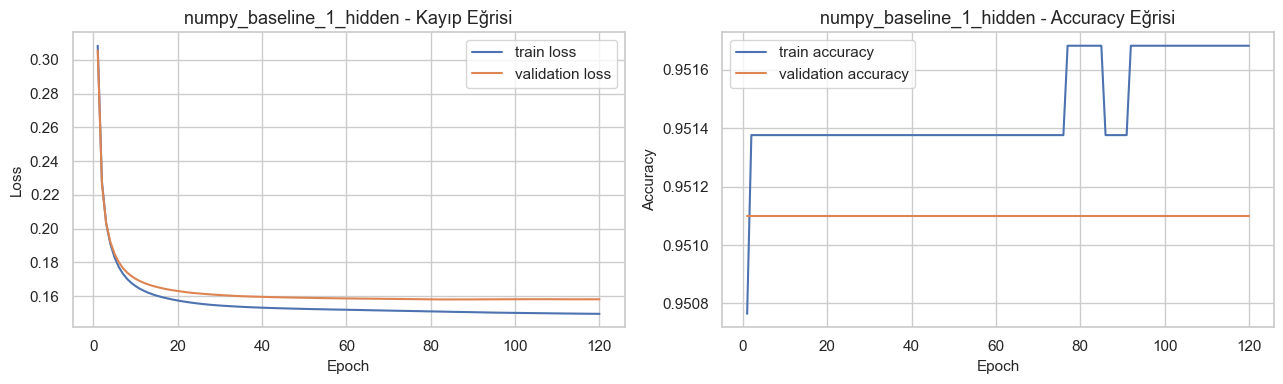

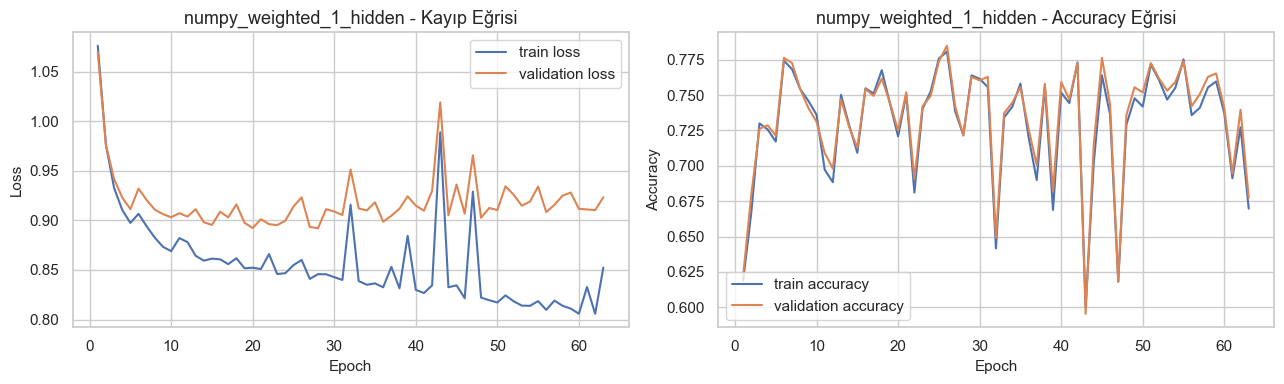

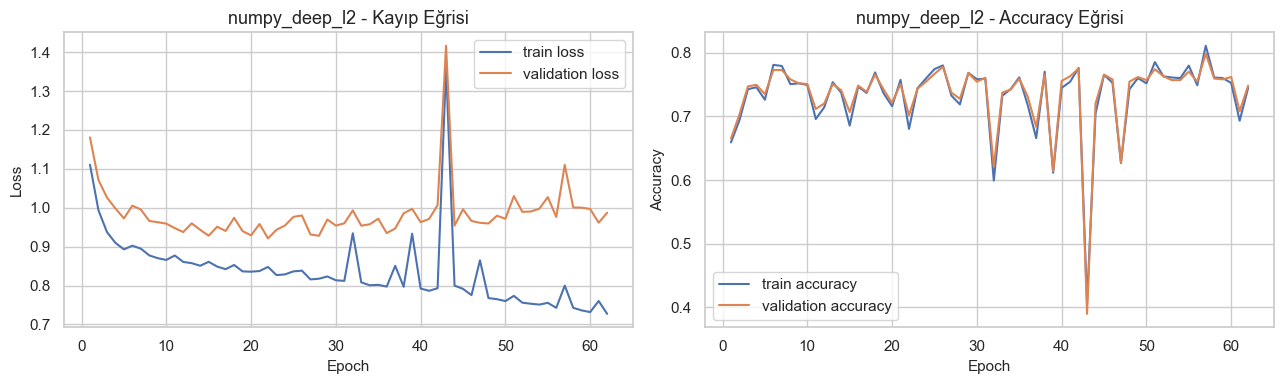

In [29]:
for model_name in custom_results["model_name"]:
    plot_history(model_store[model_name]["history"], model_name)

### NumPy Bölümü Yorumu

Buradaki temel amaç sadece daha yüksek skor elde etmek değil, model davranışını anlamaktır:

- Tek gizli katmanlı temel model, dengesiz veri yüzünden çoğu zaman negatif sınıfa kayabilir.
- Sınıf ağırlığı eklemek `recall` değerini artırabilir.
- Gizli katman sayısını artırmak her zaman daha iyi sonuç vermeyebilir; küçük ve dengesiz veri setlerinde aşırı karmaşık ağlar beklenen faydayı vermeyebilir.

,scenario,accuracy,precision,recall,f1,roc_auc
0,Varsayılan threshold = 0.50,0.9511,0.5000,0.0200,0.0385,0.8402
1,Validation ile seçilen threshold = 0.12,0.8826,0.2500,0.7000,0.3684,0.8402


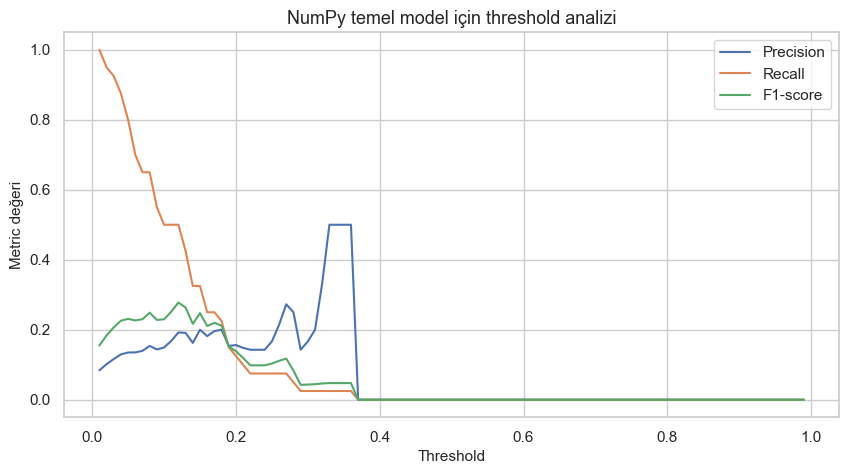

In [30]:
baseline_name = "numpy_baseline_1_hidden"
baseline_default = metric_frame(
    y_test_array,
    model_store[baseline_name]["test_prob"],
    threshold=0.50,
)
baseline_tuned = metric_frame(
    y_test_array,
    model_store[baseline_name]["test_prob"],
    threshold=model_store[baseline_name]["best_threshold"],
)

threshold_effect_table = pd.DataFrame(
    [
        {"scenario": "Varsayılan threshold = 0.50", **baseline_default},
        {
            "scenario": f"Validation ile seçilen threshold = {model_store[baseline_name]['best_threshold']:.2f}",
            **baseline_tuned,
        },
    ]
)

display(threshold_effect_table.round(4))
plot_threshold_diagnostics(
    model_store[baseline_name]["threshold_df"],
    "NumPy temel model için threshold analizi",
)

## 6. Aynı Mimarinin `scikit-learn MLPClassifier` ile Yazılması

Ödev maddelerinden biri aynı mantığın bir kütüphane yardımıyla tekrar kurulmasını istiyor. Burada:

- Temel mimari yine `1` gizli katmanlıdır.
- Optimizasyon yine `SGD` ile yapılır.
- Aynı `train / validation / test` ayrımı kullanılır.
- Aynı öğrenme oranı, batch boyutu ve epoch sayısı kullanılır.
- Aynı Xavier başlangıç ağırlıkları hem NumPy modeline hem `MLPClassifier` modeline enjekte edilir.

Böylece iki farklı implementasyon mümkün olduğunca aynı koşullarda karşılaştırılmış olur.

In [31]:
sklearn_mlp, sklearn_history = train_sklearn_with_shared_init(
    X_train_processed,
    y_train.to_numpy(),
    X_val_processed,
    y_val.to_numpy(),
    hidden_layers=(16,),
    learning_rate=0.03,
    epochs=120,
    batch_size=64,
    alpha=0.0,
    shuffle=False,
    seed=SEED,
    initial_weights=shared_baseline_weights,
    initial_biases=shared_baseline_biases,
)

sklearn_val_prob = sklearn_mlp.predict_proba(X_val_processed)[:, 1]
sklearn_test_prob = sklearn_mlp.predict_proba(X_test_processed)[:, 1]
sklearn_best_threshold, sklearn_threshold_df = find_best_threshold(y_val_array, sklearn_val_prob)

numpy_baseline_initial_check = BinaryMLP(
    input_dim=X_train_processed.shape[1],
    hidden_layers=(16,),
    learning_rate=0.03,
    epochs=1,
    batch_size=64,
    l2_lambda=0.0,
    pos_weight=1.0,
    patience=None,
    shuffle=False,
    initial_weights=shared_baseline_weights,
    initial_biases=shared_baseline_biases,
    seed=SEED,
)

initial_numpy_prob = numpy_baseline_initial_check.predict_proba(X_val_processed).ravel()
sklearn_initial_check, _ = train_sklearn_with_shared_init(
    X_train_processed,
    y_train.to_numpy(),
    X_val_processed,
    y_val.to_numpy(),
    hidden_layers=(16,),
    learning_rate=0.03,
    epochs=0,
    batch_size=64,
    alpha=0.0,
    shuffle=False,
    seed=SEED,
    initial_weights=shared_baseline_weights,
    initial_biases=shared_baseline_biases,
)
initial_sklearn_prob = sklearn_initial_check.predict_proba(X_val_processed)[:, 1]
initial_prediction_gap = float(np.max(np.abs(initial_numpy_prob - initial_sklearn_prob)))

sklearn_name = "sklearn_mlp_same_architecture"
model_store[sklearn_name] = {
    "model": sklearn_mlp,
    "implementation": "scikit-learn",
    "architecture": "(16,)",
    "epochs_run": len(sklearn_history["epoch"]),
    "val_prob": sklearn_val_prob,
    "test_prob": sklearn_test_prob,
    "best_threshold": sklearn_best_threshold,
    "threshold_df": sklearn_threshold_df,
    "history": sklearn_history,
}

sklearn_results = pd.DataFrame(
    [
        build_result_row(
            model_name=sklearn_name,
            implementation="scikit-learn",
            architecture="(16,)",
            epochs_run=len(sklearn_history["epoch"]),
            y_val_true=y_val_array,
            y_val_prob=sklearn_val_prob,
            y_test_true=y_test_array,
            y_test_prob=sklearn_test_prob,
            best_threshold=sklearn_best_threshold,
        )
    ]
)

print(f"Başlangıç tahmin farkı (NumPy vs scikit-learn, aynı ağırlıklar): {initial_prediction_gap:.10f}")
display(sklearn_results.round(4))

Başlangıç tahmin farkı (NumPy vs scikit-learn, aynı ağırlıklar): 0.0000000000


,model_name,implementation,architecture,epochs_run,threshold,val_f1,val_recall,val_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_f1_at_0_50
0,sklearn_mlp_same_architecture,scikit-learn,"(16,)",120,0.1200,0.2778,0.5000,0.8386,0.8826,0.2500,0.7000,0.3684,0.8402,0.0385


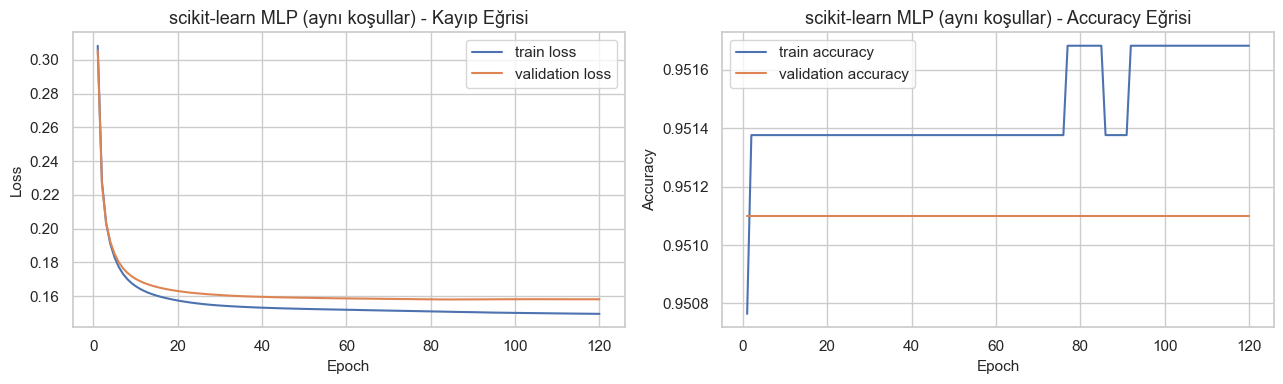

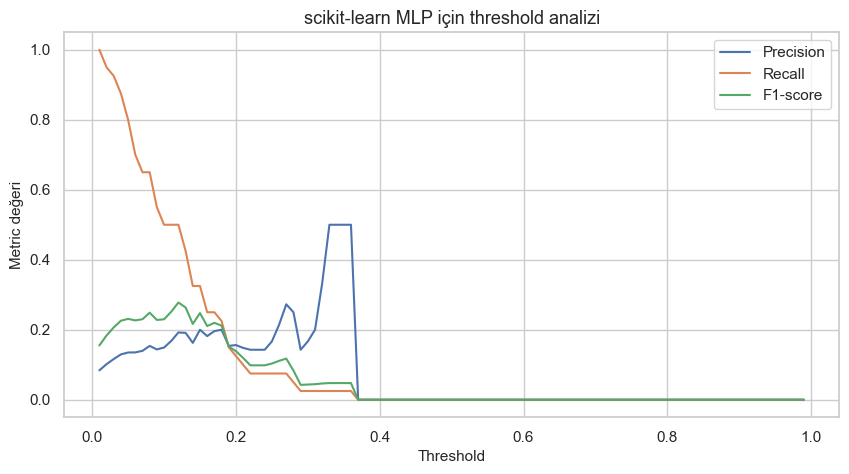

In [32]:
plot_history(sklearn_history, "scikit-learn MLP (aynı koşullar)")

plot_threshold_diagnostics(
    sklearn_threshold_df,
    "scikit-learn MLP için threshold analizi",
)

### Aynı Koşullar Altında NumPy ve scikit-learn Karşılaştırması

Aşağıdaki tablo yalnızca iki temel implementasyonu karşılaştırır. Bu iki satır için veri ayrımı, mimari, öğrenme oranı, batch boyutu, epoch sayısı ve başlangıç ağırlıkları aynıdır.

In [33]:
all_same_condition = pd.concat(
    [
        custom_results.loc[custom_results["model_name"] == "numpy_baseline_1_hidden"],
        sklearn_results,
    ],
    ignore_index=True,
)

display(all_same_condition.round(4))

,model_name,implementation,architecture,epochs_run,threshold,val_f1,val_recall,val_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_f1_at_0_50
0,numpy_baseline_1_hidden,NumPy,"(16,)",120,0.1200,0.2778,0.5000,0.8386,0.8826,0.2500,0.7000,0.3684,0.8402,0.0385
1,sklearn_mlp_same_architecture,scikit-learn,"(16,)",120,0.1200,0.2778,0.5000,0.8386,0.8826,0.2500,0.7000,0.3684,0.8402,0.0385


## 7. Modellerin Toplu Karşılaştırması

Bu tabloda tüm modeller tek yerde karşılaştırılmaktadır. Seçim ölçütü:

1. Önce `validation F1-score`
2. Eşitlik halinde `validation recall`
3. Sonra `ROC-AUC`

Bu yaklaşım, test setine bakarak model seçme hatasını azaltır.

In [34]:
all_results = (
    pd.concat([custom_results, sklearn_results], ignore_index=True)
    .sort_values(by=["val_f1", "val_recall", "val_roc_auc"], ascending=False)
    .reset_index(drop=True)
)

display(all_results.round(4))

selected_model_name = all_results.loc[0, "model_name"]
selected_model_info = model_store[selected_model_name]
selected_threshold = selected_model_info["best_threshold"]

print(f"Seçilen model: {selected_model_name}")
print(f"Seçilen threshold: {selected_threshold:.2f}")

,model_name,implementation,architecture,epochs_run,threshold,val_f1,val_recall,val_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_f1_at_0_50
0,numpy_baseline_1_hidden,NumPy,"(16,)",120,0.1200,0.2778,0.5000,0.8386,0.8826,0.2500,0.7000,0.3684,0.8402,0.0385
1,sklearn_mlp_same_architecture,scikit-learn,"(16,)",120,0.1200,0.2778,0.5000,0.8386,0.8826,0.2500,0.7000,0.3684,0.8402,0.0385
2,numpy_weighted_1_hidden,NumPy,"(16,)",63,0.8100,0.2609,0.3750,0.8415,0.9061,0.2830,0.6000,0.3846,0.8398,0.2167
3,numpy_deep_l2,NumPy,"(32, 16)",62,0.7100,0.2523,0.7000,0.8287,0.8082,0.1682,0.7400,0.2741,0.8349,0.2005


Seçilen model: numpy_baseline_1_hidden
Seçilen threshold: 0.12


## 8. Seçilen Modelin Ayrıntılı Değerlendirmesi

Şimdi validation performansına göre seçilen model için:

- Karmaşıklık matrisi
- Sınıflandırma raporu
- ROC eğrisi
- Precision-Recall eğrisi

gösterilecektir.

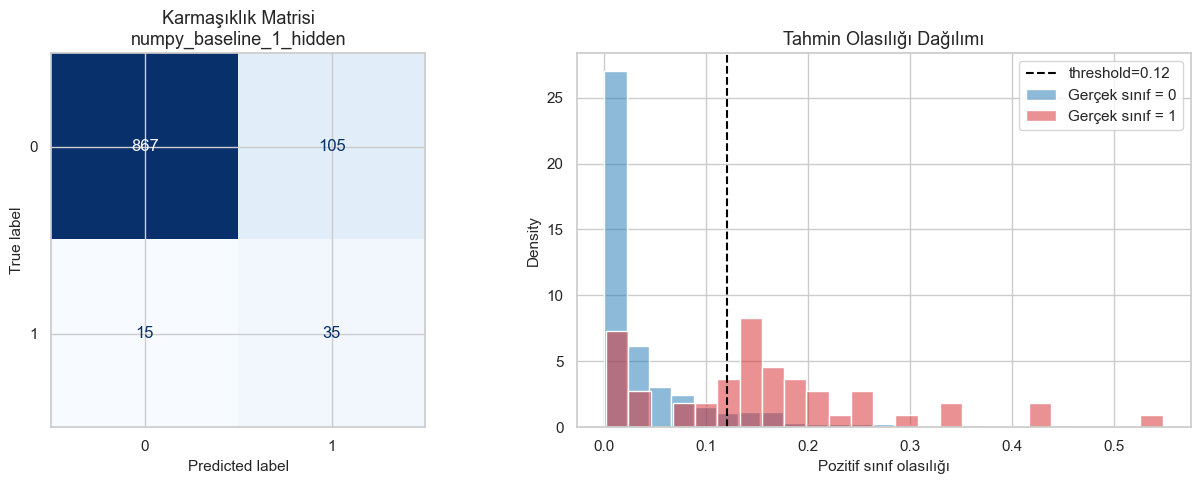

              precision    recall  f1-score   support

           0       0.98      0.89      0.94       972
           1       0.25      0.70      0.37        50

    accuracy                           0.88      1022
   macro avg       0.62      0.80      0.65      1022
weighted avg       0.95      0.88      0.91      1022



In [35]:
selected_test_prob = selected_model_info["test_prob"]
selected_test_pred = (selected_test_prob >= selected_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_array.ravel(),
    selected_test_pred,
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title(f"Karmaşıklık Matrisi\n{selected_model_name}")

sns.histplot(
    x=selected_test_prob[y_test_array.ravel() == 0],
    color="tab:blue",
    label="Gerçek sınıf = 0",
    stat="density",
    bins=25,
    alpha=0.5,
    ax=axes[1],
)
sns.histplot(
    x=selected_test_prob[y_test_array.ravel() == 1],
    color="tab:red",
    label="Gerçek sınıf = 1",
    stat="density",
    bins=25,
    alpha=0.5,
    ax=axes[1],
)
axes[1].axvline(selected_threshold, color="black", linestyle="--", label=f"threshold={selected_threshold:.2f}")
axes[1].set_title("Tahmin Olasılığı Dağılımı")
axes[1].set_xlabel("Pozitif sınıf olasılığı")
axes[1].legend()

plt.tight_layout()
plt.show()

print(classification_report(y_test_array.ravel(), selected_test_pred, zero_division=0))

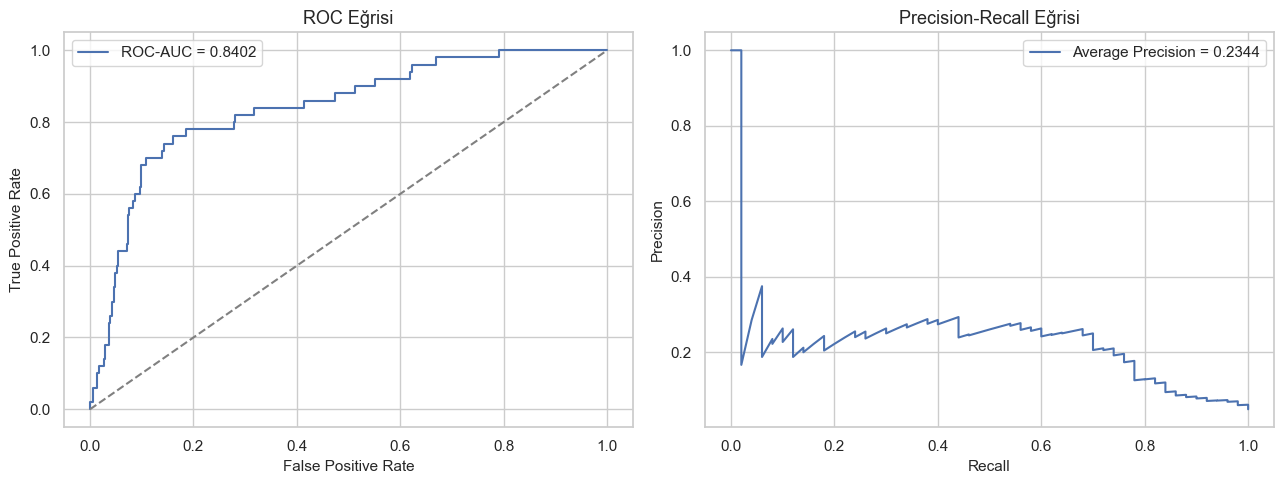

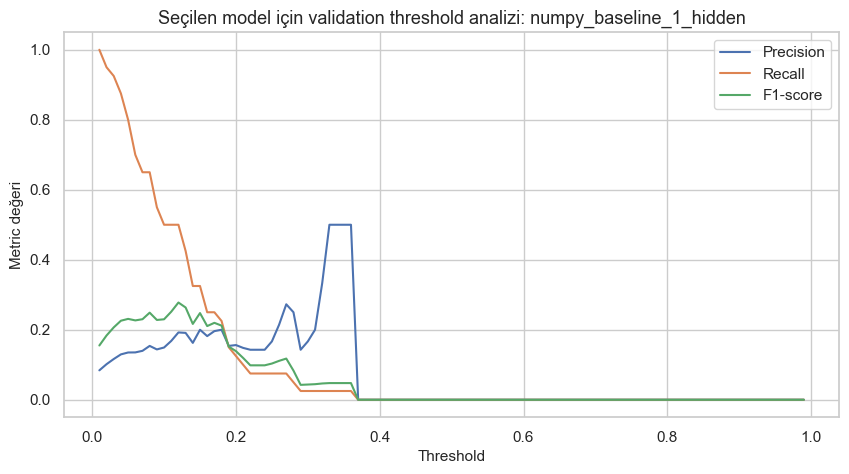

In [36]:
fpr, tpr, _ = roc_curve(y_test_array.ravel(), selected_test_prob)
precision_curve, recall_curve, _ = precision_recall_curve(y_test_array.ravel(), selected_test_prob)
average_precision = average_precision_score(y_test_array.ravel(), selected_test_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test_array.ravel(), selected_test_prob):.4f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Eğrisi")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, label=f"Average Precision = {average_precision:.4f}")
axes[1].set_title("Precision-Recall Eğrisi")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

plot_threshold_diagnostics(
    selected_model_info["threshold_df"],
    f"Seçilen model için validation threshold analizi: {selected_model_name}",
)

## 9. Sonuç

Bu notebook ile ödev maddelerinin ana bölümleri tamamlanmıştır:

- Veri analizi yapıldı.
- Gerekli ön işleme adımları uygulandı.
- Temel 1 gizli katmanlı model eğitildi ve test edildi.
- Overfitting / underfitting yorumu için eğitim ve doğrulama eğrileri incelendi.
- Daha derin / regülarize model denemeleri yapıldı.
- Aynı mimari `MLPClassifier` ile tekrar yazıldı.
- Karmaşıklık matrisi ve temel metrikler gösterildi.

Son karar, dengesiz veri yapısı nedeniyle yalnızca doğruluğa bakılarak değil; `F1`, `Recall` ve `ROC-AUC` birlikte değerlendirilerek verilmiştir.

In [37]:
best_row = all_results.iloc[0]
positive_ratio = df["stroke"].mean() * 100

summary_md = f'''
### Kısa Değerlendirme

- Veri setinde pozitif sınıf oranı yalnızca **%{positive_ratio:.2f}** olduğu için doğruluk tek başına yeterli değildir.
- Validation F1-score'a göre seçilen model: **{best_row["model_name"]}**
- Seçilen karar eşiği: **{best_row["threshold"]:.2f}**
- Test Accuracy: **{best_row["test_accuracy"]:.4f}**
- Test Precision: **{best_row["test_precision"]:.4f}**
- Test Recall: **{best_row["test_recall"]:.4f}**
- Test F1-score: **{best_row["test_f1"]:.4f}**
- Test ROC-AUC: **{best_row["test_roc_auc"]:.4f}**

Sonuç olarak, bu veri setinde sınıf dengesizliği nedeniyle **threshold ayarı** ve **recall/F1 takibi** kritik rol oynamaktadır.
'''

display(Markdown(summary_md))


### Kısa Değerlendirme

- Veri setinde pozitif sınıf oranı yalnızca **%4.87** olduğu için doğruluk tek başına yeterli değildir.
- Validation F1-score'a göre seçilen model: **numpy_baseline_1_hidden**
- Seçilen karar eşiği: **0.12**
- Test Accuracy: **0.8826**
- Test Precision: **0.2500**
- Test Recall: **0.7000**
- Test F1-score: **0.3684**
- Test ROC-AUC: **0.8402**

Sonuç olarak, bu veri setinde sınıf dengesizliği nedeniyle **threshold ayarı** ve **recall/F1 takibi** kritik rol oynamaktadır.
